In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 1 │ Imports
# All third-party dependencies are imported here so missing packages surface
# immediately before any work begins.
# ─────────────────────────────────────────────────────────────────────────────

import logging
import operator
import os
import pickle
from pathlib import Path
from typing import Annotated, List, Literal, Optional

import arxiv                                          # pip install arxiv
from dotenv import load_dotenv
from pydantic import BaseModel, Field

from langchain.chat_models import init_chat_model
from langchain_community.document_loaders import PyPDFLoader
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper
from langchain_community.vectorstores import FAISS
from langchain_core.documents import Document
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import OpenAIEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter

from langgraph.graph import END, START, StateGraph

# ── Cell health-check ────────────────────────────────────────────────────────
# Verifies all imports resolved correctly before continuing.
print("✅ Cell 1 passed — all imports resolved.")

✅ Cell 1 passed — all imports resolved.


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 2 │ Logging & Config
#
# Logging writes to BOTH the notebook console and a local file so that:
#   - Developers see real-time progress in the notebook output
#   - A permanent record is saved to disk for post-run debugging
#
# All tuneable parameters live here so developers never need to hunt
# through node functions to change settings.
# ─────────────────────────────────────────────────────────────────────────────

# ── Logging setup ────────────────────────────────────────────────────────────
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(name)s - %(message)s",
    handlers=[
        logging.FileHandler("agentic_rag.log"),   # persisted to disk
        logging.StreamHandler(),                   # visible in notebook output
    ],
)
# Silence noisy third-party HTTP logs — only show warnings and above
logging.getLogger("httpx").setLevel(logging.WARNING)
logging.getLogger("faiss").setLevel(logging.WARNING)

logger = logging.getLogger("agentic_rag")
logger.info("Logging initialised → writing to 'agentic_rag.log'")

# ── Environment ──────────────────────────────────────────────────────────────
load_dotenv()
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY", "")

# ── Tuneable parameters ───────────────────────────────────────────────────────
# Paths
#PDF_FOLDER        = Path("./pdf")            # folder containing source PDFs
#VECTORSTORE_PATH  = Path("./faiss_index")    # where the FAISS index is saved/loaded

# Hybrid chunking
#RECURSIVE_CHUNK_SIZE    = 1000   # characters — semantic-boundary splitter
#RECURSIVE_CHUNK_OVERLAP = 150    # overlap keeps context across chunk boundaries
#FIXED_CHUNK_SIZE        = 400    # characters — fine-grained fixed-size splitter
#FIXED_CHUNK_OVERLAP     = 50

# Retrieval
#TOP_K_RETRIEVAL    = 6    # how many docs to fetch from FAISS per sub-query
RELEVANCE_THRESHOLD = 0.70  # cosine similarity floor — docs below this are discarded

# Agent loop
MAX_ATTEMPTS       = 3    # maximum self-reflection retry cycles

# Models
LLM_MODEL          = "openai:gpt-4o"
EMBEDDING_MODEL    = "text-embedding-3-small"

# ── LLM & Embeddings ─────────────────────────────────────────────────────────
llm        = init_chat_model(LLM_MODEL)
embeddings = OpenAIEmbeddings(model=EMBEDDING_MODEL)
logger.info(f"LLM: {LLM_MODEL} | Embeddings: {EMBEDDING_MODEL}")

# ── Cell health-check ────────────────────────────────────────────────────────
#assert os.environ.get("OPENAI_API_KEY"), "❌ OPENAI_API_KEY not found — check your .env file."
#assert PDF_FOLDER.exists(), f"❌ PDF folder not found at '{PDF_FOLDER.resolve()}'"
print("✅ Cell 2 passed — config loaded, API key found, PDF folder exists.")

2026-02-23 21:39:20,265 [INFO] agentic_rag - Logging initialised → writing to 'agentic_rag.log'
2026-02-23 21:39:20,900 [INFO] agentic_rag - LLM: openai:gpt-4o | Embeddings: text-embedding-3-small


✅ Cell 2 passed — config loaded, API key found, PDF folder exists.


In [8]:
import os
import json
import uuid
import fitz  # PyMuPDF
import pdfplumber
import openai  # ← changed

import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image
import io
import base64
import faiss
from sentence_transformers import SentenceTransformer
from dataclasses import dataclass, field
from typing import Optional
import re
import pickle
# ─────────────────────────────────────────────────────────────────────────────
# CELL 1 │ Imports
# All third-party dependencies are imported here so missing packages surface
# immediately before any work begins.
# ─────────────────────────────────────────────────────────────────────────────

import logging
import operator
import os
import pickle
from pathlib import Path
from typing import Annotated, List, Literal, Optional

# ── Cell health-check ────────────────────────────────────────────────────────
# Verifies all imports resolved correctly before continuing.
print("✅ Cell 1 passed — all imports resolved.")

# ─────────────────────────────────────────────
# CONFIGURATION
# ─────────────────────────────────────────────

PDF_FOLDER         = "research_pdf"
OUTPUT_FOLDER      = "extracted_output"
IMAGE_FOLDER       = os.path.join(OUTPUT_FOLDER, "figures")
FAISS_INDEX_PATH   = os.path.join(OUTPUT_FOLDER, "faiss_index.bin")
METADATA_PATH      = os.path.join(OUTPUT_FOLDER, "metadata.pkl")

CHUNK_SIZE         = 800      # characters
CHUNK_OVERLAP      = 100      # characters
EMBEDDING_MODEL    = "all-MiniLM-L6-v2"  # 384-dim, fast, good for scientific text

# ── OpenAI client (replaces Anthropic client) ──────────────────────────────
openai_client = openai.OpenAI(api_key=os.environ.get("OPENAI_API_KEY"))  # ← changed

# Embedding model
embedder = SentenceTransformer(EMBEDDING_MODEL)

# Section headings common in scientific papers
SECTION_HEADINGS = [
    "abstract", "introduction", "background",
    "results", "discussion", "conclusion",
    "methods", "materials and methods", "experimental",
    "references", "acknowledgements", "supplementary"
]

# Create output directories
os.makedirs(OUTPUT_FOLDER, exist_ok=True)
os.makedirs(IMAGE_FOLDER,  exist_ok=True)


# ─────────────────────────────────────────────
# DOCUMENT CHUNK DATACLASS
# ─────────────────────────────────────────────

@dataclass
class DocumentChunk:
    chunk_id:       str
    source_file:    str
    page_number:    int
    content_type:   str          # "text" | "table" | "figure" | "caption"
    section:        str
    content:        str
    raw_table:      Optional[str] = None
    image_path:     Optional[str] = None
    chunk_index:    int = 0
    metadata:       dict = field(default_factory=dict)


# ─────────────────────────────────────────────
# STEP 1 — TEXT EXTRACTION WITH STRUCTURE
# ─────────────────────────────────────────────

def extract_text_with_structure(pdf_path: str) -> list[dict]:
    doc    = fitz.open(pdf_path)
    blocks = []

    for page_num, page in enumerate(doc):
        raw_blocks = page.get_text("dict")["blocks"]

        for block in raw_blocks:
            if block["type"] != 0:
                continue

            block_text = ""
            max_font   = 0

            for line in block["lines"]:
                for span in line["spans"]:
                    block_text += span["text"] + " "
                    if span["size"] > max_font:
                        max_font = span["size"]

            block_text = block_text.strip()
            if not block_text:
                continue

            is_heading = (
                max_font >= 11 and
                len(block_text) < 80 and
                block_text.lower().strip().rstrip(":") in SECTION_HEADINGS
            )

            blocks.append({
                "page":       page_num + 1,
                "block_type": "heading" if is_heading else "text",
                "font_size":  max_font,
                "text":       block_text,
                "bbox":       block["bbox"]
            })

    doc.close()
    return blocks


def assign_sections(blocks: list[dict]) -> list[dict]:
    current_section = "preamble"

    for block in blocks:
        if block["block_type"] == "heading":
            current_section = block["text"].strip().lower().rstrip(":")
        block["section"] = current_section

    return blocks


# ─────────────────────────────────────────────
# STEP 2 — TABLE EXTRACTION
# ─────────────────────────────────────────────

def extract_tables(pdf_path: str) -> list[dict]:
    tables = []

    with pdfplumber.open(pdf_path) as pdf:
        for page_num, page in enumerate(pdf.pages):
            page_tables = page.extract_tables()

            if not page_tables:
                continue

            for t_idx, raw_table in enumerate(page_tables):
                if not raw_table or len(raw_table) < 2:
                    continue

                header = [
                    str(cell).strip() if cell else f"col_{i}"
                    for i, cell in enumerate(raw_table[0])
                ]
                rows = []
                for row in raw_table[1:]:
                    cleaned = [str(cell).strip() if cell else "" for cell in row]
                    rows.append(cleaned)

                df       = pd.DataFrame(rows, columns=header)
                markdown = df.to_markdown(index=False)
                words    = page.extract_words()
                context_text = " ".join([w["text"] for w in words[:50]])

                tables.append({
                    "page":        page_num + 1,
                    "table_index": t_idx,
                    "dataframe":   df,
                    "markdown":    markdown,
                    "json":        df.to_json(orient="records"),
                    "context":     context_text
                })

    return tables


# ─────────────────────────────────────────────
# STEP 3 — IMAGE AND FIGURE EXTRACTION
# ─────────────────────────────────────────────

def extract_images(pdf_path: str, text_blocks: list[dict]) -> list[dict]:
    doc    = fitz.open(pdf_path)
    images = []
    source = Path(pdf_path).stem

    for page_num, page in enumerate(doc):
        image_list = page.get_images(full=True)

        for img_idx, img_ref in enumerate(image_list):
            xref = img_ref[0]

            try:
                base_image  = doc.extract_image(xref)
                image_bytes = base_image["image"]
                image_ext   = base_image["ext"]

                pil_img = Image.open(io.BytesIO(image_bytes))
                w, h    = pil_img.size
                if w < 100 or h < 100:
                    continue

                img_filename = f"{source}_page{page_num+1}_fig{img_idx}.{image_ext}"
                img_path     = os.path.join(IMAGE_FOLDER, img_filename)
                with open(img_path, "wb") as f:
                    f.write(image_bytes)

                img_rects = page.get_image_rects(xref)
                img_bbox  = img_rects[0] if img_rects else None

                caption = find_caption(text_blocks, page_num + 1, img_bbox)

                images.append({
                    "page":        page_num + 1,
                    "image_index": img_idx,
                    "image_path":  img_path,
                    "image_bytes": image_bytes,
                    "image_ext":   image_ext,
                    "bbox":        img_bbox,
                    "caption":     caption,
                    "width":       w,
                    "height":      h
                })

            except Exception as e:
                print(f"  Image extraction error page {page_num+1} idx {img_idx}: {e}")
                continue

    doc.close()
    return images


def find_caption(text_blocks: list[dict], page_num: int, img_bbox) -> str:
    if img_bbox is None:
        return ""

    img_bottom = img_bbox.y1
    candidates = []

    for block in text_blocks:
        if block["page"] != page_num:
            continue
        block_top = block["bbox"][1]

        if block_top > img_bottom and (block_top - img_bottom) < 150:
            text     = block["text"]
            priority = 0
            if re.match(r'^(fig|figure|table)', text, re.IGNORECASE):
                priority = 1
            candidates.append((block_top - img_bottom, priority, text))

    if not candidates:
        return ""

    candidates.sort(key=lambda x: (-x[1], x[0]))
    return candidates[0][2]


# ─────────────────────────────────────────────
# STEP 4 — FIGURE DESCRIPTION VIA OPENAI VISION
# Uses gpt-4o which supports vision (image input)
# ─────────────────────────────────────────────

def describe_figure_with_openai(          # ← renamed + rewritten
    image_bytes: bytes,
    image_ext:   str,
    caption:     str
) -> str:
    """
    Passes image to OpenAI GPT-4o vision and returns
    a detailed scientific description string.

    Key differences from the Claude version:
    - Uses openai.OpenAI client instead of anthropic.Anthropic
    - Model: "gpt-4o" (supports vision natively)
    - Content list format follows OpenAI's schema:
        { "type": "image_url",
          "image_url": { "url": "data:<mime>;base64,<data>" } }
    - Response accessed via .choices[0].message.content
    """
    # Build data-URI (OpenAI accepts inline base64 via data URL)
    media_type = f"image/{image_ext}" if image_ext != "jpg" else "image/jpeg"
    b64_image  = base64.standard_b64encode(image_bytes).decode("utf-8")
    data_url   = f"data:{media_type};base64,{b64_image}"  # ← OpenAI format

    caption_context = (
        f"The figure caption reads: '{caption}'" if caption
        else "No caption was extracted."
    )

    prompt = f"""You are analyzing a figure from a peer-reviewed immunology research paper.

{caption_context}

Please provide a detailed scientific description of this figure including:
1. Figure type (e.g., flow cytometry plot, western blot, immunofluorescence, bar graph, survival curve)
2. What biological entities are shown (cell types, proteins, markers)
3. Key quantitative values visible (percentages, MFI values, p-values, n values)
4. What the figure demonstrates scientifically
5. Any notable differences between experimental groups shown

Be specific and use the scientific terminology visible in the figure."""

    try:
        response = openai_client.chat.completions.create(   # ← OpenAI call
            model="gpt-4o",                                  # ← vision-capable model
            max_tokens=1000,
            messages=[
                {
                    "role": "user",
                    "content": [
                        {
                            "type":      "image_url",        # ← OpenAI image type
                            "image_url": {"url": data_url}   # ← data URI
                        },
                        {
                            "type": "text",
                            "text": prompt
                        }
                    ]
                }
            ]
        )
        return response.choices[0].message.content           # ← OpenAI response path

    except Exception as e:
        print(f"  OpenAI vision error: {e}")
        return f"Figure description unavailable. Caption: {caption}"


# ─────────────────────────────────────────────
# STEP 5 — HYBRID CHUNKING
# ─────────────────────────────────────────────

def group_blocks_by_section(blocks: list[dict]) -> dict[str, list[dict]]:
    sections = {}
    for block in blocks:
        if block["block_type"] == "heading":
            continue
        sec = block["section"]
        if sec not in sections:
            sections[sec] = []
        sections[sec].append(block)
    return sections


def recursive_split(
    text:       str,
    chunk_size: int = CHUNK_SIZE,
    overlap:    int = CHUNK_OVERLAP
) -> list[str]:
    separators = ["\n\n", "\n", ". ", " ", ""]
    chunks     = []

    def split_recursive(text: str, sep_index: int) -> list[str]:
        if len(text) <= chunk_size or sep_index >= len(separators):
            return [text.strip()] if text.strip() else []

        sep   = separators[sep_index]
        parts = text.split(sep) if sep else list(text)

        current = ""
        result  = []

        for part in parts:
            candidate = (current + sep + part).strip() if current else part

            if len(candidate) <= chunk_size:
                current = candidate
            else:
                if current:
                    result.append(current)
                if len(part) > chunk_size:
                    result.extend(split_recursive(part, sep_index + 1))
                    current = ""
                else:
                    current = part

        if current:
            result.append(current)

        return result

    raw_chunks = split_recursive(text, 0)

    for i, chunk in enumerate(raw_chunks):
        if i == 0:
            chunks.append(chunk)
        else:
            overlap_text = raw_chunks[i-1][-overlap:] if len(raw_chunks[i-1]) > overlap else raw_chunks[i-1]
            chunks.append((overlap_text + " " + chunk).strip())

    return chunks


def create_text_chunks(blocks: list[dict], source_file: str) -> list[DocumentChunk]:
    section_groups = group_blocks_by_section(blocks)
    all_chunks     = []
    chunk_counter  = 0

    for section_name, section_blocks in section_groups.items():
        section_text = " ".join([b["text"] for b in section_blocks])
        pages        = list(set([b["page"] for b in section_blocks]))
        main_page    = pages[0] if pages else 0

        if not section_text.strip():
            continue

        sub_chunks = [section_text] if len(section_text) <= CHUNK_SIZE else recursive_split(section_text)

        for sub_idx, chunk_text in enumerate(sub_chunks):
            if not chunk_text.strip():
                continue

            all_chunks.append(DocumentChunk(
                chunk_id     = str(uuid.uuid4()),
                source_file  = source_file,
                page_number  = main_page,
                content_type = "text",
                section      = section_name,
                content      = chunk_text.strip(),
                chunk_index  = chunk_counter,
                metadata     = {
                    "sub_chunk_index":  sub_idx,
                    "total_sub_chunks": len(sub_chunks),
                    "pages_covered":    pages,
                    "character_count":  len(chunk_text)
                }
            ))
            chunk_counter += 1

    return all_chunks


# ─────────────────────────────────────────────
# STEP 6 — ASSEMBLE ALL CHUNKS
# ─────────────────────────────────────────────

def create_table_chunks(
    tables:      list[dict],
    source_file: str,
    text_blocks: list[dict]
) -> list[DocumentChunk]:
    chunks = []

    for idx, table in enumerate(tables):
        section = infer_section_for_page(text_blocks, table["page"])
        content = (
            f"Table {idx+1} on page {table['page']}.\n"
            f"Context: {table['context'][:200]}\n\n"
            f"{table['markdown']}"
        )

        chunks.append(DocumentChunk(
            chunk_id     = str(uuid.uuid4()),
            source_file  = source_file,
            page_number  = table["page"],
            content_type = "table",
            section      = section,
            content      = content,
            raw_table    = table["json"],
            chunk_index  = idx,
            metadata     = {
                "table_index": table["table_index"],
                "row_count":   len(table["dataframe"]),
                "col_count":   len(table["dataframe"].columns)
            }
        ))

    return chunks


def create_figure_chunks(
    images:      list[dict],
    source_file: str,
    text_blocks: list[dict]
) -> list[DocumentChunk]:
    chunks = []

    for idx, image in enumerate(images):
        print(f"  Describing figure {idx+1}/{len(images)} with OpenAI vision...")

        description = describe_figure_with_openai(   # ← updated call
            image["image_bytes"],
            image["image_ext"],
            image["caption"]
        )

        section = infer_section_for_page(text_blocks, image["page"])
        content = (
            f"Figure on page {image['page']}.\n"
            f"Caption: {image['caption']}\n\n"
            f"Description: {description}"
        )

        chunks.append(DocumentChunk(
            chunk_id     = str(uuid.uuid4()),
            source_file  = source_file,
            page_number  = image["page"],
            content_type = "figure",
            section      = section,
            content      = content,
            image_path   = image["image_path"],
            chunk_index  = idx,
            metadata     = {
                "image_width":  image["width"],
                "image_height": image["height"],
                "has_caption":  bool(image["caption"])
            }
        ))

    return chunks


def infer_section_for_page(text_blocks: list[dict], target_page: int) -> str:
    current_section = "unknown"
    for block in text_blocks:
        if block["page"] > target_page:
            break
        if block["block_type"] == "heading":
            current_section = block["text"].lower().strip()
    return current_section


# ─────────────────────────────────────────────
# STEP 7 — FAISS VECTOR STORE
# ─────────────────────────────────────────────

def embed_chunks(chunks: list[DocumentChunk]) -> np.ndarray:
    texts = [chunk.content for chunk in chunks]
    print(f"  Embedding {len(texts)} chunks...")
    embeddings = embedder.encode(
        texts,
        batch_size=32,
        show_progress_bar=True,
        convert_to_numpy=True
    )
    return embeddings.astype(np.float32)


def build_faiss_index(embeddings: np.ndarray) -> faiss.IndexFlatL2:
    dimension = embeddings.shape[1]
    index     = faiss.IndexFlatL2(dimension)
    index.add(embeddings)
    print(f"  FAISS index built: {index.ntotal} vectors, dim={dimension}")
    return index


def save_faiss_store(
    index:         faiss.IndexFlatL2,
    chunks:        list[DocumentChunk],
    index_path:    str = FAISS_INDEX_PATH,
    metadata_path: str = METADATA_PATH
):
    faiss.write_index(index, index_path)

    metadata = [
        {
            "chunk_id":     c.chunk_id,
            "source_file":  c.source_file,
            "page_number":  c.page_number,
            "content_type": c.content_type,
            "section":      c.section,
            "content":      c.content,
            "raw_table":    c.raw_table,
            "image_path":   c.image_path,
            "chunk_index":  c.chunk_index,
            "metadata":     c.metadata
        }
        for c in chunks
    ]

    with open(metadata_path, "wb") as f:
        pickle.dump(metadata, f)

    print(f"  Saved FAISS index  → {index_path}")
    print(f"  Saved metadata     → {metadata_path} ({len(metadata)} records)")


def load_faiss_store(
    index_path:    str = FAISS_INDEX_PATH,
    metadata_path: str = METADATA_PATH
):
    index = faiss.read_index(index_path)
    with open(metadata_path, "rb") as f:
        metadata = pickle.load(f)
    return index, metadata


def query_faiss_store(
    query:          str,
    index:          faiss.IndexFlatL2,
    metadata:       list[dict],
    top_k:          int = 5,
    content_filter: Optional[str] = None
) -> list[dict]:
    query_vec          = embedder.encode([query], convert_to_numpy=True).astype(np.float32)
    distances, indices = index.search(query_vec, top_k * 3)

    results = []
    for dist, idx in zip(distances[0], indices[0]):
        if idx == -1:
            continue
        chunk_meta = metadata[idx]

        if content_filter and chunk_meta["content_type"] != content_filter:
            continue

        results.append({
            "rank":         len(results) + 1,
            "distance":     float(dist),
            "chunk_id":     chunk_meta["chunk_id"],
            "source_file":  chunk_meta["source_file"],
            "page_number":  chunk_meta["page_number"],
            "content_type": chunk_meta["content_type"],
            "section":      chunk_meta["section"],
            "content":      chunk_meta["content"],
            "image_path":   chunk_meta.get("image_path")
        })

        if len(results) >= top_k:
            break

    return results


# ─────────────────────────────────────────────
# MAIN PIPELINE ORCHESTRATOR
# ─────────────────────────────────────────────

def process_pdf(pdf_path: str) -> list[DocumentChunk]:
    source_file = Path(pdf_path).name
    print(f"\n{'='*60}")
    print(f"Processing: {source_file}")
    print(f"{'='*60}")

    all_chunks = []

    print("Step 1: Extracting text with structural metadata...")
    text_blocks = extract_text_with_structure(pdf_path)
    text_blocks = assign_sections(text_blocks)
    print(f"  Extracted {len(text_blocks)} text blocks")

    print("Step 2: Extracting tables...")
    tables = extract_tables(pdf_path)
    print(f"  Extracted {len(tables)} tables")

    print("Step 3: Extracting images and figures...")
    images = extract_images(pdf_path, text_blocks)
    print(f"  Extracted {len(images)} images")

    print("Step 4: Generating figure descriptions via OpenAI vision...")  # ← updated label
    figure_chunks = create_figure_chunks(images, source_file, text_blocks)
    all_chunks.extend(figure_chunks)
    print(f"  Created {len(figure_chunks)} figure chunks")

    print("Step 5: Applying hybrid chunking to text...")
    text_chunks = create_text_chunks(text_blocks, source_file)
    all_chunks.extend(text_chunks)
    print(f"  Created {len(text_chunks)} text chunks")

    print("Step 6: Creating table chunks...")
    table_chunks = create_table_chunks(tables, source_file, text_blocks)
    all_chunks.extend(table_chunks)
    print(f"  Created {len(table_chunks)} table chunks")

    print(f"  Total chunks for {source_file}: {len(all_chunks)}")
    return all_chunks


def main():
    pdf_folder = Path("demo_pdf/")

    if not pdf_folder.exists():
        raise FileNotFoundError(
            f"Folder '{pdf_folder}' not found. "
            "Create it and place your PDF files inside."
        )

    pdf_files = list(pdf_folder.glob("*.pdf"))

    if not pdf_files:
        raise ValueError(f"No PDF files found in '{pdf_folder}'")

    print(f"Found {len(pdf_files)} PDF files: {[f.name for f in pdf_files]}")

    all_chunks = []
    for pdf_path in pdf_files:
        chunks = process_pdf(str(pdf_path))
        all_chunks.extend(chunks)

    print(f"\nTotal chunks across all PDFs: {len(all_chunks)}")

    print("\nStep 7: Building FAISS vector store...")
    embeddings = embed_chunks(all_chunks)
    index      = build_faiss_index(embeddings)
    save_faiss_store(index, all_chunks)

    print("\n" + "="*60)
    print("SAMPLE QUERY VERIFICATION")
    print("="*60)

    loaded_index, loaded_metadata = load_faiss_store()

    test_query = "What happens to AKT phosphorylation when METTL3 is deleted in NK cells?"
    print(f"Query: {test_query}\n")

    results = query_faiss_store(
        query    = test_query,
        index    = loaded_index,
        metadata = loaded_metadata,
        top_k    = 3
    )

    for r in results:
        print(f"Rank {r['rank']} | {r['content_type'].upper()} | "
              f"{r['source_file']} | Page {r['page_number']} | "
              f"Section: {r['section']}")
        print(f"Distance: {r['distance']:.4f}")
        print(f"Content preview: {r['content'][:300]}")
        if r["image_path"]:
            print(f"Image: {r['image_path']}")
        print("-" * 40)

    print("\nPipeline complete.")
    print(f"FAISS index : {FAISS_INDEX_PATH}")
    print(f"Metadata    : {METADATA_PATH}")
    print(f"Figures     : {IMAGE_FOLDER}/")


if __name__ == "__main__":
    main()

✅ Cell 1 passed — all imports resolved.
Found 3 PDF files: ['Alkbh5 plays indispensable roles in maintaining se.pdf', 'm6A in mRNA coding regions promotes translation vi.pdf', 'The M6A methyltransferase METTL3 promotes the deve.pdf']

Processing: Alkbh5 plays indispensable roles in maintaining se.pdf
Step 1: Extracting text with structural metadata...
  Extracted 647 text blocks
Step 2: Extracting tables...
  Extracted 14 tables
Step 3: Extracting images and figures...
  Extracted 53 images
Step 4: Generating figure descriptions via OpenAI vision...
  Describing figure 1/53 with OpenAI vision...
  Describing figure 2/53 with OpenAI vision...
  Describing figure 3/53 with OpenAI vision...
  Describing figure 4/53 with OpenAI vision...
  Describing figure 5/53 with OpenAI vision...
  Describing figure 6/53 with OpenAI vision...
  Describing figure 7/53 with OpenAI vision...
  Describing figure 8/53 with OpenAI vision...
  Describing figure 9/53 with OpenAI vision...
  Describing figure 1

Batches: 100%|██████████| 11/11 [00:06<00:00,  1.58it/s]

  FAISS index built: 346 vectors, dim=384
  Saved FAISS index  → extracted_output\faiss_index.bin
  Saved metadata     → extracted_output\metadata.pkl (346 records)

SAMPLE QUERY VERIFICATION
Query: What happens to AKT phosphorylation when METTL3 is deleted in NK cells?

Rank 1 | TEXT | The M6A methyltransferase METTL3 promotes the deve.pdf | Page 3 | Section: results
Distance: 1.0257
Content preview: ), migration (I), invasion (J). Journal of Cancer  2020, Vol. 11 http://www.jcancer.org 3593 Table 1 The association between METTL3 expression and clinical  pathological characters in PCa Clinical pathological  characters Number of  cases METTL3  P-value  Low-expression  High-expression  Age (years)
----------------------------------------
Rank 2 | TEXT | The M6A methyltransferase METTL3 promotes the deve.pdf | Page 3 | Section: results
Distance: 1.0385
Content preview: tly  dysregulated in sole microarray dataset: Singh  prostate (Fig. 1C, Supplementary Table S1) [14] We  further confirm

In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 4 │ External Tools — arXiv & Wikipedia
#
# These tools are ONLY invoked when the FAISS vector store does not return
# sufficiently relevant documents (controlled by RELEVANCE_THRESHOLD in
# the Iterative Retrieval Check node).
#
# Priority order enforced by the ReAct agent (Cell 6):
#   1. FAISS (local, fast, authoritative)
#   2. arXiv (academic papers — good for technical / research questions)
#   3. Wikipedia (general background knowledge)
# ─────────────────────────────────────────────────────────────────────────────

def search_arxiv(query: str, max_results: int = 3) -> List[Document]:
    """
    Searches arXiv for papers matching *query*.
    Returns a list of Documents where page_content is the paper abstract
    and metadata contains title, authors, and PDF URL.

    Called by the ReAct agent when FAISS retrieval is insufficient.
    """
    logger.info(f"[arxiv] 🔍 Searching arXiv: '{query}'")
    try:
        client  = arxiv.Client()
        search  = arxiv.Search(query=query, max_results=max_results)
        results = list(client.results(search))

        docs = [
            Document(
                page_content=r.summary,
                metadata={
                    "source": "arxiv",
                    "title": r.title,
                    "authors": ", ".join(a.name for a in r.authors[:3]),
                    "url": r.pdf_url,
                },
            )
            for r in results
        ]
        logger.info(f"[arxiv] ✅ Retrieved {len(docs)} paper(s)")
        return docs

    except Exception as exc:
        logger.error(f"[arxiv] ❌ Search failed: {exc}")
        return []


def search_wikipedia(query: str) -> List[Document]:
    """
    Searches Wikipedia for *query* and returns the top result as a Document.
    Called by the ReAct agent as a last-resort fallback after FAISS and arXiv.
    """
    logger.info(f"[wikipedia] 🔍 Searching Wikipedia: '{query}'")
    try:
        wiki_tool = WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper(top_k_results=2))
        result    = wiki_tool.run(query)

        doc = Document(
            page_content=result,
            metadata={"source": "wikipedia", "query": query},
        )
        logger.info("[wikipedia] ✅ Retrieved Wikipedia content")
        return [doc]

    except Exception as exc:
        logger.error(f"[wikipedia] ❌ Search failed: {exc}")
        return []


# ── Cell health-check ────────────────────────────────────────────────────────
# Smoke-test: confirm the functions are callable (no live API calls here)
assert callable(search_arxiv),     "❌ search_arxiv is not callable"
assert callable(search_wikipedia), "❌ search_wikipedia is not callable"
print("✅ Cell 4 passed — external tool functions defined.")

✅ Cell 4 passed — external tool functions defined.


In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 5 │ State Schema & Prompts
#
# AgenticRAGState
# ───────────────
# The single source of truth passed between every node.  Each node reads
# relevant fields and returns state.model_copy(update={...}) with its changes.
# Using model_copy() instead of mutation keeps state immutable per LangGraph
# best-practice and makes debugging straightforward.
#
# Prompt Design Notes
# ────────────────────
# • decomposition_prompt  — instructs the LLM to output JSON, making it easy
#                           to parse sub-queries reliably.
# • cot_prompt            — includes a scratchpad section so reasoning is
#                           explicit and auditable in the logs.
# • reflection_prompt     — receives original_question (not the rewritten
#                           query) so judgment is always against user intent.
# ─────────────────────────────────────────────────────────────────────────────

# ── State Schema ─────────────────────────────────────────────────────────────

class AgenticRAGState(BaseModel):
    # ── Input ────────────────────────────────────────────────────────────────
    original_question: str              # never mutated — used by reflector
    question: str                       # current active query (may be rewritten)

    # ── Planning (Block 1) ───────────────────────────────────────────────────
    sub_queries: List[str] = []         # decomposed sub-questions

    # ── Retrieval (Blocks 3 & 4) ─────────────────────────────────────────────
    retrieved_docs: List[Document] = [] # current set of retrieved docs (replaced each loop)
    retrieval_source: str = ""          # which source was used: faiss / arxiv / wikipedia
    docs_are_relevant: bool = False     # set by iterative retrieval check node

    # ── Reasoning (Block 2) ──────────────────────────────────────────────────
    cot_reasoning: str = ""             # chain-of-thought scratchpad

    # ── Answer (Blocks 5 & 6) ────────────────────────────────────────────────
    sub_answers: List[str] = []         # one answer per sub-query
    final_answer: str = ""              # synthesised answer
    reflection: str = ""                # reflection verdict
    needs_revision: bool = False        # True → loop back for another attempt

    # ── Loop control ─────────────────────────────────────────────────────────
    attempts: int = 0


# ── Prompts ───────────────────────────────────────────────────────────────────

# 1. Query Decomposition — returns JSON list of sub-queries
decomposition_prompt = ChatPromptTemplate.from_messages([
    ("system",
     "You are a query planning assistant. "
     "Break the user question into 1–4 focused sub-questions that together fully cover the original question. "
     "If the question is already simple and focused, return it as a single-item list. "
     "Respond ONLY with a valid JSON array of strings. Example: [\"sub-q 1\", \"sub-q 2\"]"),
    ("human", "Question: {question}"),
])

# 2. Chain of Thought — forces explicit step-by-step reasoning
cot_prompt = ChatPromptTemplate.from_messages([
    ("system",
     "You are a careful analytical assistant. "
     "Before writing your answer, work through your reasoning step by step in a <scratchpad> section. "
     "Only use information from the provided context — do not invent facts. "
     "After your scratchpad, write a concise final answer."),
    ("human",
     "Context:\n{context}\n\n"
     "Sub-question: {sub_question}\n\n"
     "<scratchpad>\n(reason step by step here)\n</scratchpad>\n\n"
     "Answer:"),
])

# 3. ReAct tool-selection — chooses between faiss / arxiv / wikipedia
react_prompt = ChatPromptTemplate.from_messages([
    ("system",
     "You are a retrieval routing agent. "
     "Given the query and the relevance verdict of the last FAISS retrieval, "
     "decide which tool to use next. "
     "Rules: "
     "1. Always prefer 'faiss' if FAISS docs are relevant. "
     "2. Use 'arxiv' for academic, technical, or research topics when FAISS fails. "
     "3. Use 'wikipedia' only as a last resort for general background. "
     "Respond with exactly one word: faiss, arxiv, or wikipedia."),
    ("human",
     "Query: {query}\n"
     "FAISS docs relevant: {faiss_relevant}\n"
     "Previous source used: {previous_source}"),
])

# 4. Document relevance check — scores whether docs match the query
relevance_prompt = ChatPromptTemplate.from_messages([
    ("system",
     "You are a relevance evaluator. "
     "Given a query and a set of retrieved document excerpts, decide if the documents "
     "contain enough relevant information to answer the query. "
     "Respond ONLY with YES or NO."),
    ("human",
     "Query: {query}\n\n"
     "Documents:\n{docs_preview}"),
])

# 5. Answer Synthesis — merges multiple sub-answers into one coherent response
synthesis_prompt = ChatPromptTemplate.from_messages([
    ("system",
     "You are an answer synthesis expert. "
     "You will receive the original question and a set of partial answers, each addressing a sub-question. "
     "Synthesise them into one clear, complete, and non-repetitive final answer. "
     "If any partial answers contradict each other, note the discrepancy."),
    ("human",
     "Original question: {original_question}\n\n"
     "Partial answers:\n{sub_answers}"),
])

# 6. Self Reflection — judges if the final answer is complete
reflection_prompt = ChatPromptTemplate.from_messages([
    ("system",
     "You are a critical answer evaluator. "
     "Judge whether the answer completely and accurately addresses the original question "
     "based only on the provided context. Do NOT question whether the data is real. "
     "Respond strictly in this format:\n"
     "Reflection: YES or NO\n"
     "Explanation: <one sentence>"),
    ("human",
     "Context:\n{context}\n\n"
     "Original question: {original_question}\n\n"
     "Answer: {final_answer}"),
])

# ── Cell health-check ────────────────────────────────────────────────────────
assert AgenticRAGState.__fields__, "❌ AgenticRAGState has no fields"
assert decomposition_prompt and cot_prompt and react_prompt, "❌ One or more prompts not defined"
assert synthesis_prompt and reflection_prompt and relevance_prompt, "❌ One or more prompts not defined"
print("✅ Cell 5 passed — state schema and all 6 prompts defined.")

✅ Cell 5 passed — state schema and all 6 prompts defined.


C:\Users\Parth\AppData\Local\Temp\ipykernel_25064\3656676280.py:132: PydanticDeprecatedSince20: The `__fields__` attribute is deprecated, use the `model_fields` class property instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.12/migration/
  assert AgenticRAGState.__fields__, "❌ AgenticRAGState has no fields"


In [19]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 6 │ Node Functions
#
# Each function corresponds to one block in the diagram:
#   query_planner        → Block 1 (Yellow)  Query Planning & Decomposition
#   cot_answerer         → Block 2 (Pink)    Chain of Thought
#   react_router         → Block 3 (Red)     ReAct Tool Selection
#   iterative_retrieval  → Block 4 (Green)   Iterative Retrieval Check
#   answer_synthesiser   → Block 5 (Blue)    Answer Synthesis
#   self_reflector       → Block 6 (Orange)  Self Reflection
#
# Helper nodes:
#   faiss_retriever      → fetches docs from the local FAISS index
#   query_rewriter       → rewrites the query when reflection says NO
#   should_continue      → routing function for the conditional edge
# ─────────────────────────────────────────────────────────────────────────────

import json
import re

# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 1 — Query Planning & Decomposition (Yellow)
# ─────────────────────────────────────────────────────────────────────────────

def query_planner(state: AgenticRAGState) -> AgenticRAGState:
    """
    Decomposes *state.question* into a list of focused sub-queries.

    Why: A single broad question often retrieves vague results. Breaking it
    into narrow sub-questions allows each to pull precise, targeted chunks.

    Output: state.sub_queries — list of strings, minimum 1 item.
    """
    logger.info(f"[query_planner] Decomposing: '{state.question}'")
    try:
        chain  = decomposition_prompt | llm | StrOutputParser()
        raw    = chain.invoke({"question": state.question})
        # Strip markdown fences if model wraps output in ```json ... ```
        clean  = re.sub(r"```(?:json)?|```", "", raw).strip()
        parsed = json.loads(clean)
        sub_queries = [q.strip() for q in parsed if isinstance(q, str) and q.strip()]
        logger.info(f"[query_planner] {len(sub_queries)} sub-quer(ies): {sub_queries}")
    except Exception as exc:
        logger.error(f"[query_planner] Decomposition failed ({exc}) — using original question")
        sub_queries = [state.question]

    return state.model_copy(update={"sub_queries": sub_queries})


# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 3 — ReAct Tool Selection (Red)
# Placed before Block 2 because retrieval must happen before CoT answering.
# ─────────────────────────────────────────────────────────────────────────────

# ── Global FAISS store — loaded once at startup ───────────────────────────────
index, metadata = load_faiss_store()

def faiss_retriever(state: AgenticRAGState) -> AgenticRAGState:
    queries = state.sub_queries if state.sub_queries else [state.question]
    logger.info(f"[faiss_retriever] Querying FAISS with {len(queries)} sub-query(ies)")

    all_results = []
    seen_ids = set()

    for query in queries:
        try:
            results = query_faiss_store(
                query    = query,
                index    = index,
                metadata = metadata,
                top_k    = 4   # reduced per-query since we're querying multiple
            )
            for r in results:
                if r["chunk_id"] not in seen_ids:   # deduplicate
                    seen_ids.add(r["chunk_id"])
                    all_results.append(r)
            logger.info(f"[faiss_retriever] '{query[:60]}...' → {len(results)} doc(s)")
        except Exception as exc:
            logger.error(f"[faiss_retriever] ❌ Retrieval failed for '{query}': {exc}")

    docs = [
        Document(
            page_content = r["content"],
            metadata     = {
                "source_file":  r["source_file"],
                "page_number":  r["page_number"],
                "section":      r["section"],
                "content_type": r["content_type"],
                "image_path":   r["image_path"],
                "distance":     r["distance"],
            }
        )
        for r in all_results
    ]
    logger.info(f"[faiss_retriever] ✅ Retrieved {len(docs)} unique doc(s) total")

    return state.model_copy(update={
        "retrieved_docs":   docs,
        "retrieval_source": "faiss",
    })


def react_router(state: AgenticRAGState) -> AgenticRAGState:
    """
    ReAct routing: Reason → Act → Observe

    The LLM reasons about whether the FAISS docs are sufficient and decides
    which tool to invoke next (faiss / arxiv / wikipedia).  If a non-FAISS
    source is selected, the relevant search function is called and the docs
    are merged with any existing FAISS results.

    Priority enforced: faiss > arxiv > wikipedia
    """
    query = state.sub_queries[0] if state.sub_queries else state.question
    logger.info(f"[react_router] Deciding tool for: '{query}'")

    try:
        chain  = react_prompt | llm | StrOutputParser()
        choice = chain.invoke({
            "query":           query,
            "faiss_relevant":  str(state.docs_are_relevant),
            "previous_source": state.retrieval_source,
        }).strip().lower()
        logger.info(f"[react_router] Tool selected: '{choice}'")
    except Exception as exc:
        logger.error(f"[react_router] Routing failed ({exc}) — defaulting to faiss")
        choice = "faiss"

    new_docs = state.retrieved_docs  # start with existing docs

    if choice == "arxiv":
        arxiv_docs = search_arxiv(query)
        new_docs   = arxiv_docs + state.retrieved_docs  # arxiv results first
        source     = "arxiv"
    elif choice == "wikipedia":
        wiki_docs = search_wikipedia(query)
        new_docs  = wiki_docs + state.retrieved_docs
        source    = "wikipedia"
    else:
        # Stay with FAISS — no external call needed
        source = "faiss"

    return state.model_copy(update={
        "retrieved_docs":   new_docs,
        "retrieval_source": source,
    })


# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 4 — Iterative Retrieval Check (Green)
# ─────────────────────────────────────────────────────────────────────────────

def iterative_retrieval_check(state: AgenticRAGState) -> AgenticRAGState:
    """
    Evaluates whether the retrieved documents are relevant enough to
    answer the current sub-query BEFORE spending tokens on generation.

    Two-stage check:
      1. Fast cosine similarity check — if any doc exceeds RELEVANCE_THRESHOLD
         it is considered relevant without an LLM call (saves cost).
      2. LLM relevance judge — used when all similarity scores are borderline.

    Sets state.docs_are_relevant = True/False for downstream routing.
    """
    query = state.question
    logger.info(f"[iterative_check] Checking {len(state.retrieved_docs)} doc(s) for relevance")

    if not state.retrieved_docs:
        logger.warning("[iterative_check] No docs to evaluate → not relevant")
        return state.model_copy(update={"docs_are_relevant": False})

    # Stage 1: cosine similarity via custom FAISS (fast, no LLM call)
    try:
        results    = query_faiss_store(query=query, index=index, metadata=metadata, top_k=3)
        best_score = results[0]["distance"] if results else float("inf")
        # L2 distance — lower = more similar
        # threshold: below RELEVANCE_THRESHOLD means relevant
        if best_score < RELEVANCE_THRESHOLD:
            logger.info(f"[iterative_check] ✅ Fast check passed (distance={best_score:.3f})")
            return state.model_copy(update={"docs_are_relevant": True})
    except Exception as exc:
        logger.warning(f"[iterative_check] Similarity check error: {exc} — falling back to LLM")

    # Stage 2: LLM relevance judge (slower but more nuanced)
    docs_preview = "\n---\n".join(d.page_content[:300] for d in state.retrieved_docs[:4])
    try:
        chain  = relevance_prompt | llm | StrOutputParser()
        result = chain.invoke({"query": query, "docs_preview": docs_preview})
        is_relevant = "yes" in result.strip().lower()
        logger.info(f"[iterative_check] LLM verdict: {'RELEVANT' if is_relevant else 'NOT RELEVANT'}")
    except Exception as exc:
        logger.error(f"[iterative_check] LLM check failed: {exc} — assuming relevant")
        is_relevant = True  # fail-safe: don't stall the pipeline

    return state.model_copy(update={"docs_are_relevant": is_relevant})


# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 2 — Chain of Thought Answering (Pink)
# ─────────────────────────────────────────────────────────────────────────────

def cot_answerer(state: AgenticRAGState) -> AgenticRAGState:
    """
    Iterates over each sub-query and generates a CoT answer for each one.

    Chain of Thought forces the LLM to write explicit step-by-step reasoning
    in a <scratchpad> before committing to an answer — this reduces
    hallucination and makes the reasoning auditable in state.cot_reasoning.

    Each sub-query reuses the same retrieved_docs pool.  For a more advanced
    setup, each sub-query could trigger its own retrieval pass.
    """
    logger.info(f"[cot_answerer] Answering {len(state.sub_queries)} sub-quer(ies) (attempt {state.attempts + 1})")
    context     = "\n\n".join(d.page_content for d in state.retrieved_docs)
    sub_answers = []
    reasoning   = []

    for i, sub_q in enumerate(state.sub_queries):
        try:
            chain  = cot_prompt | llm | StrOutputParser()
            result = chain.invoke({"context": context, "sub_question": sub_q})
            # Extract scratchpad for logging and the final answer
            if "</scratchpad>" in result:
                parts     = result.split("</scratchpad>")
                scratchpad = parts[0].replace("<scratchpad>", "").strip()
                answer     = parts[1].strip()
            else:
                scratchpad = ""
                answer     = result.strip()

            reasoning.append(f"Sub-Q {i+1}: {scratchpad}")
            sub_answers.append(f"Q: {sub_q}\nA: {answer}")
            logger.info(f"[cot_answerer] Sub-Q {i+1}/{len(state.sub_queries)} answered")

        except Exception as exc:
            logger.error(f"[cot_answerer] Failed on sub-Q {i+1}: {exc}")
            sub_answers.append(f"Q: {sub_q}\nA: [Error generating answer]")

    return state.model_copy(update={
        "sub_answers":   sub_answers,
        "cot_reasoning": "\n\n".join(reasoning),
        "attempts":      state.attempts + 1,
    })


# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 5 — Answer Synthesis (Blue)
# ─────────────────────────────────────────────────────────────────────────────

def answer_synthesiser(state: AgenticRAGState) -> AgenticRAGState:
    """
    Merges all sub-answers into a single coherent final answer.

    If only one sub-query was planned the synthesis step is lightweight —
    it still runs for consistency (normalising formatting, removing
    redundancy) but does minimal work.

    Sources used are appended to the answer for transparency.
    """
    logger.info(f"[synthesiser] Synthesising {len(state.sub_answers)} sub-answer(s)")
    try:
        chain  = synthesis_prompt | llm | StrOutputParser()
        merged = chain.invoke({
            "original_question": state.original_question,
            "sub_answers":       "\n\n".join(state.sub_answers),
        })
        # Append source attribution
        source_note = f"\n\n📚 Sources used: {state.retrieval_source.upper()}"
        final       = merged.strip() + source_note
        logger.info("[synthesiser] ✅ Final answer synthesised")
    except Exception as exc:
        logger.error(f"[synthesiser] Synthesis failed: {exc}")
        final = "\n\n".join(state.sub_answers)  # fall back to concatenation

    return state.model_copy(update={"final_answer": final})


# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 6 — Self Reflection (Orange)
# ─────────────────────────────────────────────────────────────────────────────

def self_reflector(state: AgenticRAGState) -> AgenticRAGState:
    """
    Evaluates the final answer against the ORIGINAL question (not the
    rewritten query) so that judgment always reflects user intent.

    Sets state.needs_revision = True if the answer is incomplete, which
    causes the graph to loop back through query_rewriter → retrieval.
    Loops are capped by MAX_ATTEMPTS to prevent infinite cycles.
    """
    logger.info(f"[reflector] Reflecting on answer (attempt {state.attempts})")
    context = "\n\n".join(d.page_content for d in state.retrieved_docs)

    try:
        chain  = reflection_prompt | llm | StrOutputParser()
        result = chain.invoke({
            "context":           context,
            "original_question": state.original_question,
            "final_answer":      state.final_answer,
        })
        is_good = "reflection: yes" in result.lower()
        logger.info(f"[reflector] {'✅ APPROVED' if is_good else '🔁 NEEDS REVISION'}")
    except Exception as exc:
        logger.error(f"[reflector] Reflection failed: {exc} — approving to avoid loop")
        result  = "Error during reflection."
        is_good = True

    return state.model_copy(update={
        "reflection":     result,
        "needs_revision": not is_good,
    })


# ─────────────────────────────────────────────────────────────────────────────
# Helper — Query Rewriter (used when reflection says NO)
# ─────────────────────────────────────────────────────────────────────────────

rewrite_prompt = ChatPromptTemplate.from_messages([
    ("system",
     "You are a search query optimiser. "
     "Given the original question and why the previous answer was insufficient, "
     "rewrite the query to be more specific and likely to retrieve better documents. "
     "Return ONLY the rewritten query, no explanation."),
    ("human",
     "Original question: {question}\n"
     "Why it failed: {reflection}\n\n"
     "Rewritten query:"),
])

def query_rewriter(state: AgenticRAGState) -> AgenticRAGState:
    """
    Rewrites state.question based on the reflection feedback so that the
    next retrieval pass searches for something meaningfully different.
    Falls back to the original question if the rewrite fails.
    """
    logger.info("[query_rewriter] Rewriting query based on reflection")
    try:
        chain        = rewrite_prompt | llm | StrOutputParser()
        new_question = chain.invoke({
            "question":   state.original_question,
            "reflection": state.reflection,
        }).strip()
        logger.info(f"[query_rewriter] New query: '{new_question}'")
    except Exception as exc:
        logger.error(f"[query_rewriter] Rewrite failed: {exc} — keeping original")
        new_question = state.original_question

    return state.model_copy(update={
        "question":   new_question,
        "sub_queries": [],   # reset so query_planner re-decomposes the new question
    })


# ─────────────────────────────────────────────────────────────────────────────
# Routing function — controls the self-reflection loop exit condition
# ─────────────────────────────────────────────────────────────────────────────

def should_continue(state: AgenticRAGState) -> str:
    """
    Returns 'query_rewriter' if the answer needs revision and attempts remain.
    Returns END otherwise.
    """
    if not state.needs_revision:
        logger.info("[router] Answer approved → END")
        return END
    if state.attempts >= MAX_ATTEMPTS:
        logger.warning(f"[router] Max attempts ({MAX_ATTEMPTS}) reached → END")
        return END
    logger.info(f"[router] Needs revision (attempt {state.attempts}) → query_rewriter")
    return "query_rewriter"


def should_call_react(state: AgenticRAGState) -> str:
    """
    After the iterative relevance check:
      - If docs are relevant → proceed directly to CoT answering
      - If not relevant     → run ReAct to select a different source
    """
    if state.docs_are_relevant:
        logger.info("[router] Docs relevant → cot_answerer")
        return "cot_answerer"
    logger.info("[router] Docs not relevant → react_router")
    return "react_router"


# ── Cell health-check ────────────────────────────────────────────────────────
node_fns = [query_planner, faiss_retriever, react_router, iterative_retrieval_check,
            cot_answerer, answer_synthesiser, self_reflector, query_rewriter]
assert all(callable(fn) for fn in node_fns), "❌ One or more node functions are not callable"
print("✅ Cell 6 passed — all node functions defined.")


✅ Cell 6 passed — all node functions defined.


2026-02-23 22:06:43,049 [INFO] agentic_rag - LangGraph compiled successfully


✅ Cell 7 passed — graph compiled.


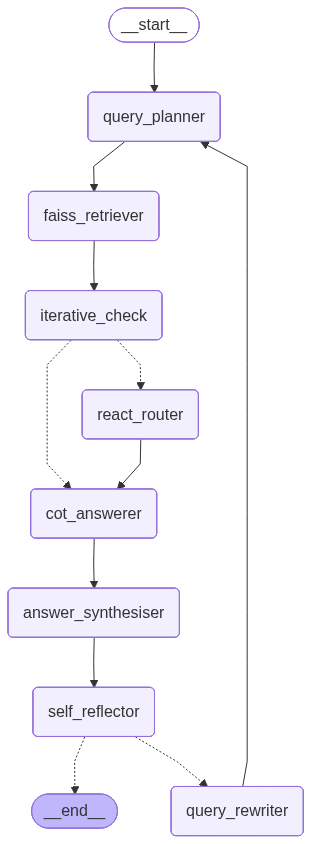

In [20]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 7 │ LangGraph DAG
#
# Graph wiring mirrors the 6-block diagram.
# path_map is provided on every conditional edge so LangGraph can render
# the full graph topology even before execution.
# ─────────────────────────────────────────────────────────────────────────────

builder = StateGraph(AgenticRAGState)

# ── Register nodes ───────────────────────────────────────────────────────────
builder.add_node("query_planner",        query_planner)
builder.add_node("faiss_retriever",      faiss_retriever)
builder.add_node("iterative_check",      iterative_retrieval_check)
builder.add_node("react_router",         react_router)
builder.add_node("cot_answerer",         cot_answerer)
builder.add_node("answer_synthesiser",   answer_synthesiser)
builder.add_node("self_reflector",       self_reflector)
builder.add_node("query_rewriter",       query_rewriter)

# ── Wire edges ────────────────────────────────────────────────────────────────
builder.add_edge(START,                  "query_planner")
builder.add_edge("query_planner",        "faiss_retriever")
builder.add_edge("faiss_retriever",      "iterative_check")

# After relevance check: relevant → answer directly, not relevant → ReAct
builder.add_conditional_edges(
    "iterative_check",
    should_call_react,
    path_map=["cot_answerer", "react_router"],
)

# ReAct always feeds into CoT answering after fetching external docs
builder.add_edge("react_router",         "cot_answerer")
builder.add_edge("cot_answerer",         "answer_synthesiser")
builder.add_edge("answer_synthesiser",   "self_reflector")

# Self-reflection loop: approved → END, needs revision → rewrite → re-plan
builder.add_conditional_edges(
    "self_reflector",
    should_continue,
    path_map=["query_rewriter", END],
)

# After rewriting, go back to query_planner to re-decompose the new question
builder.add_edge("query_rewriter",       "query_planner")

# ── Compile ──────────────────────────────────────────────────────────────────
graph = builder.compile()
logger.info("LangGraph compiled successfully")

# ── Cell health-check ────────────────────────────────────────────────────────
assert graph is not None, "❌ Graph failed to compile"
print("✅ Cell 7 passed — graph compiled.")
graph   # renders the visual diagram in the notebook

In [21]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 8 │ Run the Agent
#
# Modify USER_QUERY to test different questions.
# All intermediate state is accessible in `result` for debugging.
# ─────────────────────────────────────────────────────────────────────────────

USER_QUERY = "Does $m^{6}A$ methylation in the coding region (CDS) increase or decrease translation efficiency, and how does this contrast with its effect in the 3' UTR?"

logger.info(f"{'='*60}")
logger.info(f"Starting Agentic RAG | Question: '{USER_QUERY}'")
logger.info(f"{'='*60}")

init_state = AgenticRAGState(
    question=USER_QUERY,
    original_question=USER_QUERY,
)

result = graph.invoke(init_state)

logger.info(f"Agent finished | Attempts: {result['attempts']} | Source: {result['retrieval_source']}")

# ── Display results ───────────────────────────────────────────────────────────
print("\n" + "="*60)
print("🗂️  SUB-QUERIES PLANNED:")
for i, sq in enumerate(result["sub_queries"], 1):
    print(f"   {i}. {sq}")

print("\n" + "="*60)
print(f"📡 RETRIEVAL SOURCE: {result['retrieval_source'].upper()}")

print("\n" + "="*60)
print("🧠 FINAL ANSWER:")
print(result["final_answer"])

print("\n" + "="*60)
print("🔍 REFLECTION:")
print(result["reflection"])

print("\n" + "="*60)
print(f"🔄 TOTAL ATTEMPTS: {result['attempts']}")

2026-02-23 22:06:43,394 [INFO] agentic_rag - ============================================================
2026-02-23 22:06:43,395 [INFO] agentic_rag - Starting Agentic RAG | Question: 'Does $m^{6}A$ methylation in the coding region (CDS) increase or decrease translation efficiency, and how does this contrast with its effect in the 3' UTR?'
2026-02-23 22:06:43,396 [INFO] agentic_rag - ============================================================
2026-02-23 22:06:43,402 [INFO] agentic_rag - [query_planner] Decomposing: 'Does $m^{6}A$ methylation in the coding region (CDS) increase or decrease translation efficiency, and how does this contrast with its effect in the 3' UTR?'
2026-02-23 22:06:45,040 [INFO] agentic_rag - [query_planner] 3 sub-quer(ies): ['Does m6A methylation in the coding region (CDS) increase or decrease translation efficiency?', "How does m6A methylation in the 3' UTR affect translation efficiency?", "How does the effect of m6A methylation in the CDS contrast with its eff


🗂️  SUB-QUERIES PLANNED:
   1. Does m6A methylation in the coding region (CDS) increase or decrease translation efficiency?
   2. How does m6A methylation in the 3' UTR affect translation efficiency?
   3. How does the effect of m6A methylation in the CDS contrast with its effect in the 3' UTR?

📡 RETRIEVAL SOURCE: FAISS

🧠 FINAL ANSWER:
m^6A methylation has different effects on translation efficiency depending on its location within the mRNA. In the coding region (CDS), m^6A methylation is associated with decreased translation efficiency. This reduction occurs because m^6A in the CDS can lead to the pausing of elongating ribosomes, thereby acting as a translational barrier. On the other hand, while the specific effects of m^6A methylation in the 3' UTR on translation efficiency were not explicitly detailed, it is generally understood to support translation, potentially by enhancing mRNA stability and preventing degradation. This implies that, unlike in the CDS, m^6A methylation in th

In [22]:
# ── Load store once ───────────────────────────────────────────────────────────
index, metadata = load_faiss_store()

# ── Test query ────────────────────────────────────────────────────────────────
query = "Does m6A methylation in the coding region (CDS) increase or decrease translation efficiency?"

results = query_faiss_store(
    query    = query,
    index    = index,
    metadata = metadata,
    top_k    = 6
)

# ── Diagnostic output ─────────────────────────────────────────────────────────
print(f"\n{'='*60}")
print(f"QUERY: {query}")
print(f"Total chunks retrieved: {len(results)}")
print(f"{'='*60}")

for r in results:
    print(f"\nRank {r['rank']} | Distance: {r['distance']:.4f}")
    print(f"  Source   : {r['source_file']}")
    print(f"  Page     : {r['page_number']}")
    print(f"  Section  : {r['section']}")
    print(f"  Type     : {r['content_type']}")
    print(f"  Content  : {r['content'][:300]}")
    print(f"{'-'*60}")

Batches: 100%|██████████| 1/1 [00:00<00:00, 111.15it/s]


QUERY: Does m6A methylation in the coding region (CDS) increase or decrease translation efficiency?
Total chunks retrieved: 6

Rank 1 | Distance: 0.5582
  Source   : m6A in mRNA coding regions promotes translation vi.pdf
  Page     : 1
  Section  : preamble
  Type     : text
  Content  : ARTICLE m 6 A in mRNA coding regions promotes translation via   the   RNA   helicase-containing   YTHDC2 Yuanhui   Mao 1 ,   Leiming   Dong 1 ,   Xiao-Min   Liu 1 ,   Jiayin   Guo 2 ,   Honghui   Ma 3 ,   Bin   Shen 2   &   Shu-Bing   Qian 1 * Dynamic   mRNA   modi ﬁ cation   in   the   form   of   
------------------------------------------------------------

Rank 2 | Distance: 0.5685
  Source   : m6A in mRNA coding regions promotes translation vi.pdf
  Page     : 1
  Section  : preamble
  Type     : text
  Content  : in one regional m 6 A (Fig.  1 b). Only a few messengers harbor   m 6 A   in   all   three   regions To   reveal   possible   relationships between regional methylation and gene functio